In [9]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import defaultdict
from pathlib import Path
from huggingface_hub import login
from transformers import pipeline

#login(token="hf_YOUR_TOKEN_HERE")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right': False,
})


In [ ]:
# ── LLM Configuration ────────────────────────────────────────────────────────
# Point MODEL_ID at a HuggingFace model ID or a local model directory.
# Options:
#   Qwen/Qwen3-8B     (recommended — fast, fits in 4-bit)
#   Qwen/Qwen3-14B
#   Qwen/Qwen3-32B
MODEL_ID       = "Qwen/Qwen3-8B"
LOAD_IN_4BIT   = True   # set False if you have >20 GB VRAM free
MAX_NEW_TOKENS = 256

import os, torch
from transformers import pipeline, BitsAndBytesConfig

print(f"Loading {MODEL_ID} …")

_quant_cfg = BitsAndBytesConfig(load_in_4bit=True) if LOAD_IN_4BIT else None
_llm_pipe = pipeline(
    "text-generation",
    model=MODEL_ID,
    device_map="auto",
    model_kwargs={"quantization_config": _quant_cfg} if _quant_cfg else {},
    torch_dtype=torch.bfloat16 if not LOAD_IN_4BIT else None,
)

print("Model loaded.")

# Replace the model's saved generation_config (which has max_length=20) with a
# clean one so it never conflicts with the max_new_tokens we pass per call.
import warnings
from transformers import GenerationConfig
_llm_pipe.model.generation_config = GenerationConfig()
_llm_pipe.tokenizer.clean_up_tokenization_spaces = False

# Set transformers log level to ERROR so generation warnings are suppressed.
# This uses transformers' own API which covers all its sub-loggers.
import transformers as _tf
_tf.logging.set_verbosity_error()
warnings.filterwarnings('ignore', category=FutureWarning, module='bitsandbytes')


def call_llm(prompt: str, max_new_tokens: int = MAX_NEW_TOKENS) -> str:
    """Send a prompt to the loaded LLM and return the generated text."""
    # /no_think disables Qwen3's extended reasoning mode so the model outputs
    # the JSON answer directly instead of filling tokens with a <think> block.
    messages = [{"role": "user", "content": "/no_think\n" + prompt}]
    output = _llm_pipe(messages, max_new_tokens=max_new_tokens, do_sample=False)
    return output[0]["generated_text"][-1]["content"]


def extract_json(text: str) -> dict:
    """Extract JSON object from LLM output with multi-strategy fallback."""
    # strip <think>…</think> blocks emitted by Qwen3 and other reasoning models
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()
    # markdown fenced block
    m = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass
    # bare {...}
    m = re.search(r'\{.*\}', text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass
    return {}


Loading Qwen/Qwen3-8B …


[transformers] Current model requires 512 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
Loading weights: 100%|██████████| 399/399 [05:18<00:00,  1.25it/s]


Model loaded.


In [11]:
# ── Load game JSON ─────────────────────────────────────────────────────────────
GAME_JSON_PATH = 'games/Italy-fullagent-thinking-cunning2.json'   # <- change this path or replace with inline JSON

with open(GAME_JSON_PATH) as f:
    game = json.load(f)

AGENT_POWER = 'ITALY'          # <- change to the power your agent played

print(f"Game ID  : {game.get('id', 'unknown')}")
print(f"Agent    : {AGENT_POWER}")
print(f"Phases   : {len(game['phases'])}")
print(f"Scoring  : {game.get('scoring_system', 'unknown')}")


Game ID  : JJBWt9bROaaN
Agent    : ITALY
Phases   : 17
Scoring  : sum_of_squares


In [12]:
# ── Helper: extract movement phases only ──────────────────────────────────────
def is_movement_phase(phase_name: str) -> bool:
    """True for S/F movement phases (e.g. S1901M, F1902M)."""
    return phase_name.endswith('M') and not phase_name.endswith('R')

def phase_year(phase_name: str) -> int:
    """Extract year from phase name, e.g. 'S1901M' -> 1901."""
    m = re.search(r'(\d{4})', phase_name)
    return int(m.group(1)) if m else 0

phases         = game['phases']
move_phases    = [p for p in phases if is_movement_phase(p['name'])]
all_powers     = ['AUSTRIA', 'ENGLAND', 'FRANCE', 'GERMANY', 'ITALY', 'RUSSIA', 'TURKEY']
WIN_THRESHOLD  = 18

# All standard Diplomacy location abbreviations (3-letter codes)
ALL_LOCS = {
    'ANK','ARM','BLA','SMY','CON','SYR','ADR','AEG','ALB','APU','TRI','VEN',
    'TYR','VIE','BUD','GAL','BOH','SIL','WAR','MOS','STP','LVN','PRU','BAL',
    'BER','KIE','DEN','HEL','HOL','BEL','PIC','PAR','BRE','GAS','SPA','POR',
    'MAR','LYO','WES','NAF','TUN','ION','TYS','NAP','ROM','EAS','GRE','SER',
    'BUL','RUM','SEV','UKR','BOT','FIN','SWE','NWY','BAR','NWG','NAO','MAO',
    'IRI','ENG','NTH','SKA','EDI','LVP','LON','YOR','WAL','CLY','NOR',
    'BUD','TRI','PIE','TUS','MUN','RUH','BUR','EDI',
}

def extract_mentioned_locations(text: str) -> set:
    """Find Diplomacy location codes mentioned in a message string."""
    tokens = re.findall(r'\b([A-Z]{3})\b', text.upper())
    return {t for t in tokens if t in ALL_LOCS}

def extract_order_locations(orders: list) -> set:
    """Extract all location codes appearing in a list of order strings."""
    locs = set()
    for order in orders:
        tokens = re.findall(r'\b([A-Z]{2,3})(?:/[NS][CE])?\b', order.upper())
        locs.update(t[:3] for t in tokens if t[:3] in ALL_LOCS)
    return locs

print(f"Movement phases : {len(move_phases)}")


Movement phases : 8


In [13]:
def compute_win(game: dict, power: str, threshold: int = 18) -> dict:
    """
    Determine outcome for `power` in a single game.
    Returns {'won': bool, 'final_sc': int, 'eliminated': bool}.
    """
    won = False
    final_sc = 0
    for phase in game['phases']:
        centers  = phase.get('state', {}).get('centers', {})
        sc_count = len(centers.get(power, []))
        if sc_count >= threshold:
            won = True
        final_sc = sc_count
    eliminated = (final_sc == 0)
    return {'won': won, 'final_sc': final_sc, 'eliminated': eliminated}

outcome = compute_win(game, AGENT_POWER)
print(f"Result      : {'WIN' if outcome['won'] else 'LOSS'}")
print(f"Final SCs   : {outcome['final_sc']}")
print(f"Eliminated  : {outcome['eliminated']}")
win_rate_single = 1.0 if outcome['won'] else 0.0
print(f"\nWin rate (this game): {win_rate_single:.0%}")


Result      : LOSS
Final SCs   : 0
Eliminated  : True

Win rate (this game): 0%


Average SCs across all phases: 2.82
 phase  year  sc_count
F1903M  1903         4
F1903R  1903         4
W1903A  1903         2
S1904M  1904         2
S1904R  1904         2
F1904M  1904         2
F1904R  1904         2
W1904A  1904         0


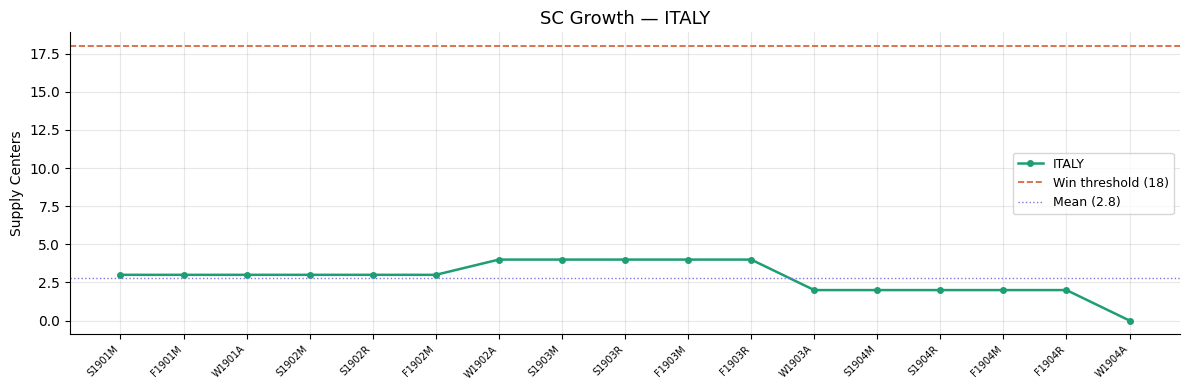

In [14]:
def compute_sc_growth(game: dict, power: str) -> pd.DataFrame:
    """Returns a DataFrame with columns [phase, year, sc_count]."""
    rows = []
    for phase in game['phases']:
        centers = phase.get('state', {}).get('centers', {})
        if centers:
            rows.append({
                'phase':    phase['name'],
                'year':     phase_year(phase['name']),
                'sc_count': len(centers.get(power, [])),
            })
    return pd.DataFrame(rows)

sc_df  = compute_sc_growth(game, AGENT_POWER)
avg_sc = sc_df['sc_count'].mean()
print(f"Average SCs across all phases: {avg_sc:.2f}")
print(sc_df.tail(8).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(sc_df)), sc_df['sc_count'], marker='o', markersize=4,
        linewidth=1.8, color='#1D9E75', label=AGENT_POWER)
ax.axhline(WIN_THRESHOLD, color='#D85A30', linewidth=1.2, linestyle='--', label='Win threshold (18)')
ax.axhline(avg_sc, color='#7F77DD', linewidth=1, linestyle=':', label=f'Mean ({avg_sc:.1f})')
ax.set_xticks(range(len(sc_df)))
ax.set_xticklabels(sc_df['phase'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Supply Centers')
ax.set_title(f'SC Growth — {AGENT_POWER}', fontsize=13, fontweight='normal')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Plan-Action Alignment Rate: 0.0%
Evaluated phases: 7


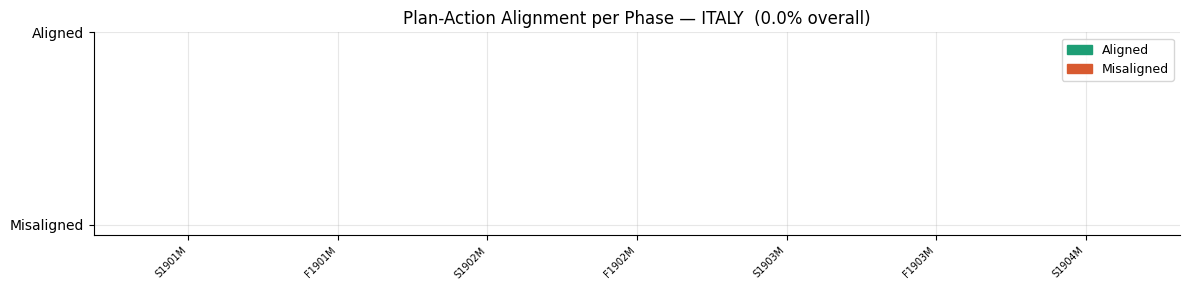

In [15]:
def compute_plan_action_alignment(game: dict, power: str) -> dict:
    """
    For each movement phase, compares location codes in the agent's messages
    against actual order locations. A phase 'aligns' if at least one mentioned
    location appears in the orders.
    """
    details = []
    for phase in game['phases']:
        if not is_movement_phase(phase['name']):
            continue
        msgs   = [m for m in phase.get('messages', []) if m.get('sender') == power]
        orders = phase.get('orders', {}).get(power, [])
        if not msgs or not orders:
            continue
        msg_text       = ' '.join(m['message'] for m in msgs)
        mentioned_locs = extract_mentioned_locations(msg_text)
        order_locs     = extract_order_locations(orders)
        aligned        = bool(mentioned_locs & order_locs)
        details.append({
            'phase':          phase['name'],
            'mentioned_locs': mentioned_locs,
            'order_locs':     order_locs,
            'aligned':        aligned,
            'n_messages':     len(msgs),
            'n_orders':       len(orders),
        })
    if not details:
        return {'alignment_rate': None, 'phase_details': []}
    alignment_rate = sum(d['aligned'] for d in details) / len(details)
    return {'alignment_rate': alignment_rate, 'phase_details': details}

paa  = compute_plan_action_alignment(game, AGENT_POWER)
rate = paa['alignment_rate']
print(f"Plan-Action Alignment Rate: {rate:.1%}" if rate is not None else "Not enough data")
print(f"Evaluated phases: {len(paa['phase_details'])}")

paa_df = pd.DataFrame(paa['phase_details'])
if not paa_df.empty:
    paa_df['aligned_int'] = paa_df['aligned'].astype(int)
    fig, ax = plt.subplots(figsize=(12, 3))
    colors = ['#1D9E75' if a else '#D85A30' for a in paa_df['aligned']]
    ax.bar(range(len(paa_df)), paa_df['aligned_int'], color=colors, width=0.6)
    ax.set_xticks(range(len(paa_df)))
    ax.set_xticklabels(paa_df['phase'], rotation=45, ha='right', fontsize=7)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Misaligned', 'Aligned'])
    ax.set_title(f'Plan-Action Alignment per Phase — {AGENT_POWER}  ({rate:.1%} overall)',
                 fontsize=12, fontweight='normal')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#1D9E75', label='Aligned'),
                       Patch(color='#D85A30', label='Misaligned')], fontsize=9)
    plt.tight_layout()
    plt.show()


Found alliance proposal
  -> Found reply sent at 135420 (proposal sent at 60201)
  -> Proposal got an ambiguous reply from AUSTRIA
Found alliance proposal
  -> Found reply sent at 110630 (proposal sent at 73983)
  -> Proposal accepted by FRANCE
Found alliance proposal
  -> Found reply sent at 93611 (proposal sent at 88828)
  -> Proposal got an ambiguous reply from TURKEY
Found alliance proposal
  -> Found reply sent at 139195 (proposal sent at 129977)
  -> Proposal accepted by FRANCE
Found alliance proposal
  -> Found reply sent at 139693 (proposal sent at 131177)
  -> Proposal accepted by GERMANY
Found alliance proposal
  -> Found reply sent at 169321 (proposal sent at 156846)
  -> Proposal got an ambiguous reply from AUSTRIA
Found alliance proposal
  -> Found reply sent at 191778 (proposal sent at 183375)
  -> Proposal accepted by TURKEY
Found alliance proposal
  -> Found reply sent at 206855 (proposal sent at 189860)
  -> Proposal accepted by FRANCE
Found alliance proposal
  -> Foun

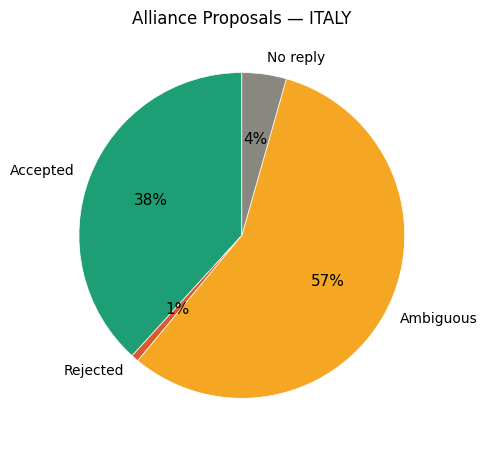


Proposals:


,phase,to,message,reply,result,confidence
0,S1901M,AUSTRIA,Italy has no interest in conflict with Austria. We suggest we both maintain neut...,That is good news to hear. It is best if we leave our border neutral. If you can send ...,ambiguous,1.0
1,S1901M,FRANCE,"France, I propose a mutual non-aggression pact. We could support each other’s mo...","I'd be down with a non-aggression pact, that sounds like an excellent plan!",accepted,1.0
2,S1901M,TURKEY,"Turkey, I admire your strength in the East. Let us remain on good terms—Italy wi...",I appreciate that Italy. Good luck to you this game.,ambiguous,1.0
3,S1901M,FRANCE,"France, your support would be most welcome along our shared border. I suggest we...",That sounds excellent! I look forward to working with you.,accepted,1.0
4,S1901M,GERMANY,"Germany, a partnership against Austria sounds intriguing. I have no immediate pl...",Absolutely. I'd be happy to work together. I'd imagine you're planning on opening in a...,accepted,1.0
5,S1901M,AUSTRIA,Your suggestion is quite reasonable. I will consider moving a unit closer to PIE...,I agree. I hope to see you succeed in moving to Pie so we can help each other out.,ambiguous,1.0
6,S1901M,TURKEY,I admire your strength and would be delighted to maintain peaceful relations. Le...,Agreed.,accepted,1.0
7,S1901M,FRANCE,Agreed—let us both focus on securing our regions for now. Perhaps we can coordin...,Sounds good!,accepted,1.0
8,S1901M,TURKEY,"Agreed, stability in the Eastern Mediterranean benefits both of us. I look forwa...","Very fair, and I will likely be in the same position.",ambiguous,1.0
9,S1901M,FRANCE,"France, I am pleased we agree. Let us keep the door open for Mediterranean coope...",Absolutely!,accepted,1.0


In [16]:
# ── Few-shot prompts ───────────────────────────────────────────────────────────
_ALLIANCE_PROPOSAL_PROMPT = """\
You are an expert Diplomacy game analyst. Classify whether the following message is an alliance proposal.

An **alliance proposal** explicitly suggests ongoing cooperation, mutual defense, or a coordinated long-term strategy between two powers — e.g. "let's ally", "non-aggression pact", "let's carve up the board", "work together against X".

A message is NOT an alliance proposal if it only:
- Requests a one-time military action (support, move, hold, convoy)
- Shares information or asks a question without proposing cooperation
- Issues a threat or a warning

Respond with only a JSON object: {{"is_alliance_proposal": true}} or {{"is_alliance_proposal": false}}

Examples:
---
Message: "I believe we could benefit from a strategic alliance. With our mutual interests in controlling key supply centers in the Mediterranean, coordinating our efforts could lead to greater success. Let's discuss potential cooperation."
{{"is_alliance_proposal": true}}
---
Message: "I see that we both have interests in the Adriatic and the Balkans. Perhaps we could coordinate our movements to prevent other powers from gaining too much influence in the region. Let's discuss a possible alliance. "
{{"is_alliance_proposal": true}}
---
Message: "What if we form a non-aggression pact? I won't move into Bohemia if you stay out of Galicia."
{{"is_alliance_proposal": true}}
---
Message: "Can you support my army from Munich into Burgundy this turn?"
{{"is_alliance_proposal": false}}
---
Message: "I'm moving to Tyrolia. Just letting you know."
{{"is_alliance_proposal": false}}
---
Message: "What are your plans for the fall phase?"
{{"is_alliance_proposal": false}}
---
Message: "{message}"
"""

_ALLIANCE_RESPONSE_PROMPT = """\
You are an expert Diplomacy game analyst. A power sent an alliance proposal. Classify the reply.

- **accepted**: Clearly agrees to cooperate or form the proposed alliance.
- **rejected**: Clearly refuses or declines the alliance.
- **ambiguous**: Neither clearly accepts nor rejects (e.g. stalling, vague, off-topic).

Respond with only a JSON object: {{"response": "accepted"}}, {{"response": "rejected"}}, or {{"response": "ambiguous"}}

Examples:
---
Reply: "Yes! I'm fully on board. Italy and Austria against the world — let's do it."
{{"response": "accepted"}}
---
Reply: "Sounds good. I look forward to talking more."
{{"response": "accepted"}}
---
Reply: "I'm not interested in an alliance right now. I have other plans."
{{"response": "rejected"}}
---
Reply: "No thanks — I'd rather keep my options open."
{{"response": "rejected"}}
---
Reply: "Hmm, interesting. Let me think about it and get back to you."
{{"response": "ambiguous"}}
---
Reply: "I need more time to evaluate the board situation."
{{"response": "ambiguous"}}
---
Reply: "{reply}"
"""


def sort_replies(replies: list) -> list:
    return sorted(replies, key=lambda m: m["time_sent"])


def classify_alliance_proposal(message: str) -> dict:
    prompt = _ALLIANCE_PROPOSAL_PROMPT.format(message=message.replace('"', "'"))
    raw = call_llm(prompt, max_new_tokens=60)
    parsed = extract_json(raw)
    is_proposal = bool(parsed.get("is_alliance_proposal", False))
    return {"is_alliance_proposal": is_proposal, "confidence": 1.0}


def classify_alliance_response(timestamp: int, replies: list) -> dict:
    if not replies:
        return {"response": "no_reply", "confidence": 1.0}
    content = ""
    for reply in replies:
        if reply["time_sent"] > timestamp:
            content = reply["message"]
            print(f"  -> Found reply sent at {reply['time_sent']} (proposal sent at {timestamp})")
            break
    if content == "":
        return {"response": "no_reply", "confidence": 1.0}
    prompt = _ALLIANCE_RESPONSE_PROMPT.format(reply=content.replace('"', "'"))
    raw = call_llm(prompt, max_new_tokens=60)
    parsed = extract_json(raw)
    response = parsed.get("response", "ambiguous")
    if response not in ("accepted", "rejected", "ambiguous"):
        response = "ambiguous"
    return {"reply": content, "response": response, "confidence": 1.0}


def compute_alliance_formation_rate(game: dict, power: str) -> dict:
    proposals = []
    accepted = rejected = ambiguous = no_reply = 0

    for phase in game["phases"]:
        messages = phase.get("messages", [])
        by_sr = defaultdict(list)
        for m in messages:
            by_sr[(m["sender"], m["recipient"])].append(m)

        for msg in messages:
            if msg["sender"] != power:
                continue
            clf = classify_alliance_proposal(msg["message"])
            if not clf["is_alliance_proposal"]:
                continue
            print("Found alliance proposal")

            recipient = msg["recipient"]
            replies   = sort_replies(by_sr.get((recipient, power), []))
            resp      = classify_alliance_response(msg["time_sent"], replies)
            outcome   = resp["response"]

            if outcome == "accepted":
                print(f"  -> Proposal accepted by {recipient}")
                accepted += 1
            elif outcome == "rejected":
                print(f"  -> Proposal rejected by {recipient}")
                rejected += 1
            elif outcome == "ambiguous":
                print(f"  -> Proposal got an ambiguous reply from {recipient}")
                ambiguous += 1
            else:
                print(f"  -> No reply from {recipient}")
                no_reply += 1
            proposals.append({
                "phase":      phase["name"],
                "to":         recipient,
                "message":    msg["message"][:80] + ("..." if len(msg["message"]) > 80 else ""),
                "reply":      resp.get("reply", ""),
                "result":     outcome,
                "confidence": resp["confidence"],
            })

    total = len(proposals)
    return {
        "alliance_formation_rate": accepted / total if total else None,
        "total_proposals": total,
        "accepted":  accepted,
        "rejected":  rejected,
        "ambiguous": ambiguous,
        "no_reply":  no_reply,
        "proposals": proposals,
    }


afr  = compute_alliance_formation_rate(game, AGENT_POWER)
rate = afr["alliance_formation_rate"]
print(f"Alliance Formation Rate : {rate:.1%}" if rate is not None else "No proposals found")
print(f"Total proposals          : {afr['total_proposals']}")
print(f"  Accepted               : {afr['accepted']}")
print(f"  Rejected               : {afr['rejected']}")
print(f"  Ambiguous              : {afr['ambiguous']}")
print(f"  No reply               : {afr['no_reply']}")

if afr["total_proposals"] > 0:
    labels  = ["Accepted", "Rejected", "Ambiguous", "No reply"]
    vals    = [afr["accepted"], afr["rejected"], afr["ambiguous"], afr["no_reply"]]
    colors  = ["#1D9E75", "#D85A30", "#F5A623", "#888780"]
    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct="%1.0f%%", startangle=90,
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    for t in autotexts:
        t.set_fontsize(11)
    ax.set_title(f"Alliance Proposals — {AGENT_POWER}", fontsize=12, fontweight="normal")
    plt.tight_layout()
    plt.show()

print("\nProposals:")
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(afr["proposals"]).head(10)


In [17]:
_PERSUASION_PROMPT = """\
You are an expert Diplomacy game analyst. Classify whether the following message is a persuasion attempt — i.e., a request for the recipient to perform a specific military action (move, support, hold, convoy, retreat) this phase.

A **military order request** asks another power to take a specific action with their units. It typically mentions a territory, unit type, or action verb like "support", "move", "hold", "convoy".

A message is NOT a military order request if it only:
- Proposes a long-term alliance or general cooperation
- Shares information or discusses the board situation
- Asks questions without requesting a specific action

Respond with only a JSON object: {{"is_persuasion_attempt": true}} or {{"is_persuasion_attempt": false}}

Examples:
---
Message: "Can you support my army from Munich into Burgundy?"
{{"is_persuasion_attempt": true}}
---
Message: "Please move your fleet to the North Sea this turn — I need it there."
{{"is_persuasion_attempt": true}}
---
Message: "If you hold in Budapest, I can guarantee your safety."
{{"is_persuasion_attempt": true}}
---
Message: "Could you convoy my army from London to Norway?"
{{"is_persuasion_attempt": true}}
---
Message: "Let's form an alliance and work together this game."
{{"is_persuasion_attempt": false}}
---
Message: "What are your plans for the fall phase?"
{{"is_persuasion_attempt": false}}
---
Message: "I think France is the biggest threat on the board right now."
{{"is_persuasion_attempt": false}}
---
Message: "I'm moving to Trieste regardless of what you do."
{{"is_persuasion_attempt": false}}
---
Message: "{message}"
"""


def classify_persuasion_attempt(message: str) -> dict:
    prompt = _PERSUASION_PROMPT.format(message=message.replace('"', "'"))
    raw = call_llm(prompt, max_new_tokens=60)
    parsed = extract_json(raw)
    is_attempt = bool(parsed.get("is_persuasion_attempt", False))
    return {"is_persuasion_attempt": is_attempt, "confidence": 1.0}


def compute_persuasion_success_rate(game: dict, power: str) -> dict:
    successes = failures = 0
    details = []

    for phase in game["phases"]:
        if not is_movement_phase(phase["name"]):
            continue
        messages = phase.get("messages", [])
        orders   = phase.get("orders", {})

        for msg in messages:
            if msg["sender"] != power:
                continue
            clf = classify_persuasion_attempt(msg["message"])
            if not clf["is_persuasion_attempt"]:
                continue

            requested_locs = extract_mentioned_locations(msg["message"]) & ALL_LOCS
            if not requested_locs:
                continue

            recipient  = msg["recipient"]
            order_locs = extract_order_locations(orders.get(recipient, []))
            success    = bool(requested_locs & order_locs)

            if success:
                successes += 1
            else:
                failures += 1

            details.append({
                "phase":          phase["name"],
                "to":             recipient,
                "requested_locs": requested_locs,
                "order_locs":     order_locs,
                "success":        success,
                "message":        msg["message"][:80],
                "confidence":     clf["confidence"],
            })

    total = successes + failures
    return {
        "persuasion_success_rate": successes / total if total else None,
        "total_attempts": total,
        "successes":      successes,
        "failures":       failures,
        "details":        details,
    }


psr  = compute_persuasion_success_rate(game, AGENT_POWER)
rate = psr["persuasion_success_rate"]
print(f"Persuasion Success Rate : {rate:.1%}" if rate is not None else "No persuasion attempts found")
print(f"Total attempts           : {psr['total_attempts']}")
print(f"  Successes              : {psr['successes']}")
print(f"  Failures               : {psr['failures']}")

if psr["total_attempts"] > 0:
    detail_df = pd.DataFrame(psr["details"])
    by_phase  = detail_df.groupby("phase")["success"].agg(["sum", "count"]).reset_index()
    by_phase.columns = ["phase", "successes", "total"]
    by_phase["rate"] = by_phase["successes"] / by_phase["total"]

    fig, ax = plt.subplots(figsize=(12, 4))
    bar_colors = ["#1D9E75" if r >= 0.5 else "#D85A30" for r in by_phase["rate"]]
    ax.bar(range(len(by_phase)), by_phase["rate"], color=bar_colors, width=0.6)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticks(range(len(by_phase)))
    ax.set_xticklabels(by_phase["phase"], rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Success Rate")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Persuasion Success Rate per Phase — {AGENT_POWER}  ({rate:.1%} overall)",
                 fontsize=12, fontweight="normal")
    plt.tight_layout()
    plt.show()

print("\nSample attempts:")
if psr["details"]:
    display(pd.DataFrame(psr["details"])[["phase", "to", "requested_locs", "success", "message"]].head(10))
else:
    print("No persuasion attempts detected.")


KeyboardInterrupt: 

In [ ]:
summary = {
    'Win Rate (this game)':    f"{win_rate_single:.0%}",
    'Average SCs':             f"{avg_sc:.1f}",
    'Plan-Action Alignment':   f"{paa['alignment_rate']:.1%}" if paa['alignment_rate'] is not None else 'N/A',
    'Alliance Formation Rate': f"{afr['alliance_formation_rate']:.1%}" if afr['alliance_formation_rate'] is not None else 'N/A',
    'Persuasion Success Rate': f"{psr['persuasion_success_rate']:.1%}" if psr['persuasion_success_rate'] is not None else 'N/A',
}

print(f"\n{'='*45}")
print(f"  EVALUATION SUMMARY — {AGENT_POWER}")
print(f"{'='*45}")
for k, v in summary.items():
    print(f"  {k:<30} {v}")
print(f"{'='*45}\n")

numeric_metrics = {
    'Win Rate':          win_rate_single,
    'Avg SCs\n(norm.)': min(avg_sc / WIN_THRESHOLD, 1.0),
    'Plan\nAlignment':  paa['alignment_rate'] if paa['alignment_rate'] is not None else 0,
    'Alliance\nFormation': afr['alliance_formation_rate'] if afr['alliance_formation_rate'] is not None else 0,
    'Persuasion\nSuccess': psr['persuasion_success_rate'] if psr['persuasion_success_rate'] is not None else 0,
}

labels  = list(numeric_metrics.keys())
values  = list(numeric_metrics.values())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values += values[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.plot(angles, values, linewidth=1.8, linestyle='solid', color='#1D9E75')
ax.fill(angles, values, alpha=0.2, color='#1D9E75')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title(f'Agent Performance — {AGENT_POWER}', fontsize=13, fontweight='normal', pad=20)
plt.tight_layout()
plt.show()


In [ ]:
# ── Multi-setting Evaluation ───────────────────────────────────────────────────
# Expected directory layout:
#
#   GAMES_ROOT/
#     setting_A/        ← one subfolder per experimental setting / run config
#         game1.json
#         game2.json
#     setting_B/
#         game3.json
#         game4.json
#
# Each subfolder is treated as one "setting". All JSON files inside are evaluated
# and aggregated together. EVAL_POWER must be the same across all games.

GAMES_ROOT = Path('games/')
EVAL_POWER = AGENT_POWER   # or override: EVAL_POWER = 'FRANCE'

setting_results: dict[str, pd.DataFrame] = {}

for setting_dir in sorted(GAMES_ROOT.iterdir()):
    if not setting_dir.is_dir():
        continue
    game_files = sorted(setting_dir.glob('*.json'))
    if not game_files:
        continue

    print(f"\n── Setting: {setting_dir.name}  ({len(game_files)} games) ──")
    rows = []
    for path in game_files:
        with open(path) as f:
            g = json.load(f)
        win_g = compute_win(g, EVAL_POWER)
        sc_g  = compute_sc_growth(g, EVAL_POWER)
        paa_g = compute_plan_action_alignment(g, EVAL_POWER)
        afr_g = compute_alliance_formation_rate(g, EVAL_POWER)
        psr_g = compute_persuasion_success_rate(g, EVAL_POWER)
        rows.append({
            'game':     path.stem,
            'won':      win_g['won'],
            'final_sc': win_g['final_sc'],
            'avg_sc':   sc_g['sc_count'].mean() if not sc_g.empty else 0,
            'paa':      paa_g['alignment_rate'],
            'afr':      afr_g['alliance_formation_rate'],
            'psr':      psr_g['persuasion_success_rate'],
        })
        status = "WIN" if win_g['won'] else "loss"
        print(f"  {path.stem:35s}  {status}  SCs={win_g['final_sc']}")

    df = pd.DataFrame(rows)
    setting_results[setting_dir.name] = df
    print(f"  → Win Rate: {df['won'].mean():.1%}   Avg SCs: {df['avg_sc'].mean():.1f}")

if not setting_results:
    print(f"No setting subfolders found under '{GAMES_ROOT}'.")
    print("Create one subfolder per setting and place game JSONs inside.")
else:
    # ── Aggregate summary across settings ──────────────────────────────────────
    agg_rows = []
    for setting, df in setting_results.items():
        agg_rows.append({
            'Setting':             setting,
            'Games':               len(df),
            'Win Rate':            df['won'].mean(),
            'Avg SCs':             df['avg_sc'].mean(),
            'Plan-Action Align':   df['paa'].mean(skipna=True),
            'Alliance Form. Rate': df['afr'].mean(skipna=True),
            'Persuasion Rate':     df['psr'].mean(skipna=True),
        })
    agg_df = pd.DataFrame(agg_rows).set_index('Setting')

    print(f"\n{'─'*60}")
    print(f"  Cross-setting summary — {EVAL_POWER}")
    print(f"{'─'*60}")
    display_df = agg_df.copy()
    for col in ['Win Rate', 'Plan-Action Align', 'Alliance Form. Rate', 'Persuasion Rate']:
        display_df[col] = display_df[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else 'N/A')
    display_df['Avg SCs'] = display_df['Avg SCs'].map(lambda x: f"{x:.1f}")
    print(display_df.to_string())

    # ── Bar chart comparison across settings ───────────────────────────────────
    rate_metrics = ['Win Rate', 'Plan-Action Align', 'Alliance Form. Rate', 'Persuasion Rate']
    n_metrics    = len(rate_metrics)
    n_settings   = len(agg_df)
    colors       = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 5), sharey=False)
    if n_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, rate_metrics):
        vals = agg_df[metric].values
        bars = ax.bar(range(n_settings), vals, color=colors[:n_settings], width=0.6)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_xticks(range(n_settings))
        ax.set_xticklabels(list(agg_df.index), rotation=30, ha='right', fontsize=8)
        ax.set_title(metric, fontsize=10)
        ax.set_ylim(0, 1.05)
        for bar, val in zip(bars, vals):
            if pd.notna(val):
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                        f"{val:.0%}", ha='center', va='bottom', fontsize=8)

    fig.suptitle(f'Multi-setting Comparison — {EVAL_POWER}', fontsize=13, fontweight='normal')
    plt.tight_layout()
    plt.show()
